In [73]:
# Import
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/boston_housing.csv', encoding='latin-1')
print(df.head())
pd.set_option('display.max_info_columns', 100)
df.info()

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   LSTAT  MEDV  
0   4.98  24.0  
1   9.14  21.6  
2   4.03  34.7  
3   2.94  33.4  
4   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE

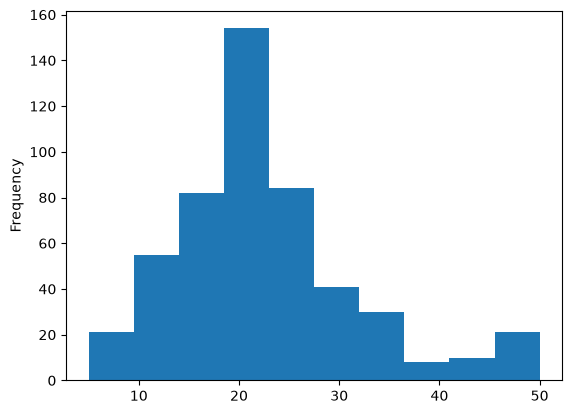

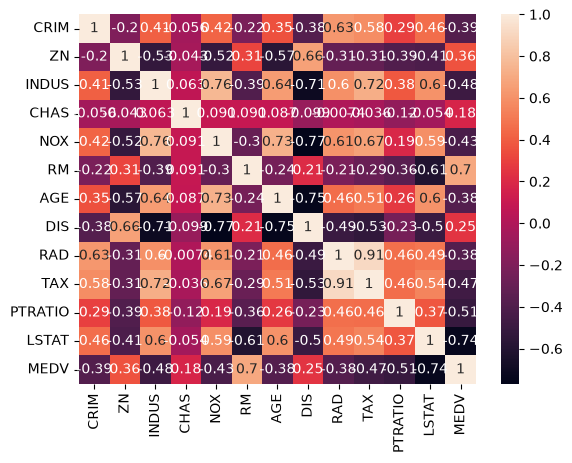

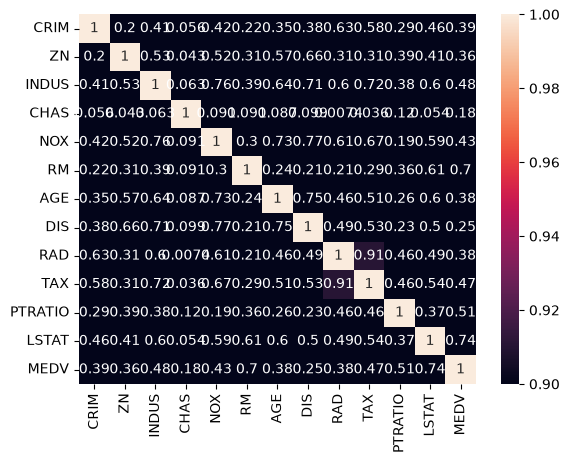

In [74]:
# Draw a graph for class balance
df['MEDV'].plot(kind="hist")
plt.show()

# Draw a correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# check coliearity
corr = df.corr(numeric_only=True).abs()
sns.heatmap(corr, vmin=0.9, vmax=1, annot=True)
plt.show()

Best feature: LSTAT
Train score: 0.7376
Test score:  0.7050
Train score: 0.7359
Test score:  0.7026


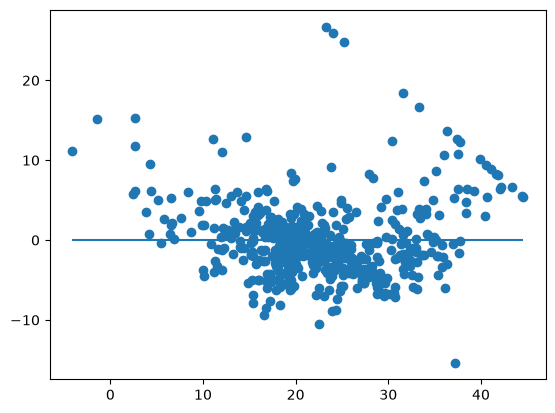

r2: 0.729848415380485
MSE: 22.806076868464267
MAE: 3.402936787662006


In [75]:
# Split into input/output
X = df.drop(columns="MEDV")
y = df["MEDV"]

# SelectK 
from sklearn.feature_selection import SelectKBest, f_regression
kselect = SelectKBest(k=1, score_func=f_regression)
X_best = kselect.fit_transform(X, y)
best_feature = X.columns[kselect.get_support()][0]
print(f'Best feature: {best_feature}')

# train, test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123321)

# from sklearn.preprocessing import PolynomialFeatures

# apply 2nd order polynomial expansion
# poly = PolynomialFeatures(degree=2)
# X_train_poly = poly.fit_transform(X_train)
# X_test_poly = poly.transform(X_test)

# fit ridge model to expanded features
# model_poly = Ridge()
# model_poly.fit(X_train_poly, y_train)

# scores
# print(f'Train score: {model_poly.score(X_train_poly, y_train):.4f}')
# print(f'Test score:  {model_poly.score(X_test_poly, y_test):.4f}')

# residuals
# y_pred_poly = model_poly.predict(X_test_poly)
# residuals = y_test - y_pred_poly
# plt.scatter(y_pred_poly, residuals)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.title('Residual Plot - Polynomial Features')
# plt.xlabel('Predicted')
# plt.ylabel('Residuals')
# plt.show()

from sklearn.preprocessing import StandardScaler

# scale input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit ridge model to scaled features
model_scaled = Ridge()
model_scaled.fit(X_train_scaled, y_train)

# scores
# print(f'Train score: {model_scaled.score(X_train_scaled, y_train):.4f}')
# print(f'Test score:  {model_scaled.score(X_test_scaled, y_test):.4f}')

# residuals
# y_pred_scaled = model_scaled.predict(X_test_scaled)
# residuals = y_test - y_pred_scaled
# plt.scatter(y_pred_scaled, residuals)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.title('Residual Plot - Scaled Features')
# plt.xlabel('Predicted')
# plt.ylabel('Residuals')
# plt.show()

# fit ridge model
from sklearn.linear_model import Ridge
model = Ridge()
model.fit(X_train, y_train)

# model_alpha = Ridge(alpha=10.0)
# model_alpha.fit(X_train, y_train)

# print(f'Train score: {model_alpha.score(X_train, y_train):.4f}')
# print(f'Test score:  {model_alpha.score(X_test, y_test):.4f}')
from sklearn.linear_model import SGDRegressor

model_sgd = SGDRegressor()
model_sgd.fit(X_train_scaled, y_train)

print(f'Train score: {model_sgd.score(X_train_scaled, y_train):.4f}')
print(f'Test score:  {model_sgd.score(X_test_scaled, y_test):.4f}')

# print the scores
print(f'Train score: {model.score(X_train, y_train):.4f}')
print(f'Test score:  {model.score(X_test, y_test):.4f}')
# 0.7359 / 0.7026 == good fit

# residual plot
preds = model.predict(X)
plt.scatter(preds, y - preds)
plt.hlines(y=0, xmin=preds.min(), xmax=preds.max())
plt.show()

# estimator metrics (r2, MSE, MAE)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print(f'r2: {r2_score(y, preds)}')
print(f'MSE: {mean_squared_error(y, preds)}')
print(f'MAE: {mean_absolute_error(y, preds)}')